In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from statsmodels.tsa import stl
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

import yfinance as yf
from warnings import filterwarnings
filterwarnings("ignore")

In [2]:
df = yf.download('MSFT', start='2015-01-01', group_by='column')

[*********************100%***********************]  1 of 1 completed


In [3]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,MSFT,MSFT,MSFT,MSFT,MSFT
Date,,,,,
2015-01-02,39.767673,40.328979,39.580574,39.682628,27913900
2015-01-05,39.401993,39.742176,39.333954,39.436009,39673900
2015-01-06,38.823677,39.759186,38.730126,39.444515,36447900
2015-01-07,39.316944,39.512550,38.687603,39.104328,29114100
2015-01-08,40.473572,40.609646,39.733669,39.759182,29645200


In [4]:
df.tail()

Price,Close,High,Low,Open,Volume
Ticker,MSFT,MSFT,MSFT,MSFT,MSFT
Date,,,,,
2026-04-13,384.369995,384.540009,371.019989,373.609985,35745800
2026-04-14,393.109985,394.690002,386.519989,387.920013,37504500
2026-04-15,411.220001,414.369995,396.730011,398.000000,45063400
2026-04-16,420.260010,420.820007,412.140015,419.859985,41642400
2026-04-17,422.790009,431.579987,420.690002,424.820007,47812100


In [5]:
# Flatten the columns by keeping only the second level (i.e., drop 'Price')
df.columns = df.columns.droplevel(1)

In [6]:
df.head()

Price,Close,High,Low,Open,Volume
Date,,,,,
2015-01-02,39.767673,40.328979,39.580574,39.682628,27913900
2015-01-05,39.401993,39.742176,39.333954,39.436009,39673900
2015-01-06,38.823677,39.759186,38.730126,39.444515,36447900
2015-01-07,39.316944,39.512550,38.687603,39.104328,29114100
2015-01-08,40.473572,40.609646,39.733669,39.759182,29645200


In [7]:
# df.to_excel('Microsoft.xlsx')

In [8]:
stock_data = pd.DataFrame(df['Close'],columns=['Close'])

In [9]:
stock_data.head()

,Close
Date,
2015-01-02,39.767673
2015-01-05,39.401993
2015-01-06,38.823677
2015-01-07,39.316944
2015-01-08,40.473572



# Data cleaning ,Data visualization and EDA


In [10]:
#Summary statistics
stock_data.describe()

,Close
count,2839.000000
mean,211.030937
std,144.986514
min,34.358738
25%,71.989063
50%,198.464279
75%,322.184753
max,539.825256


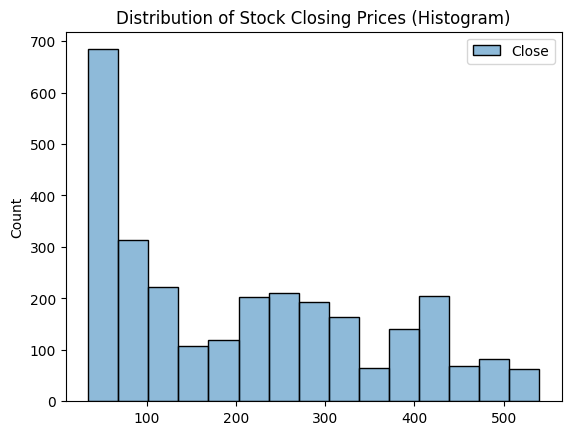

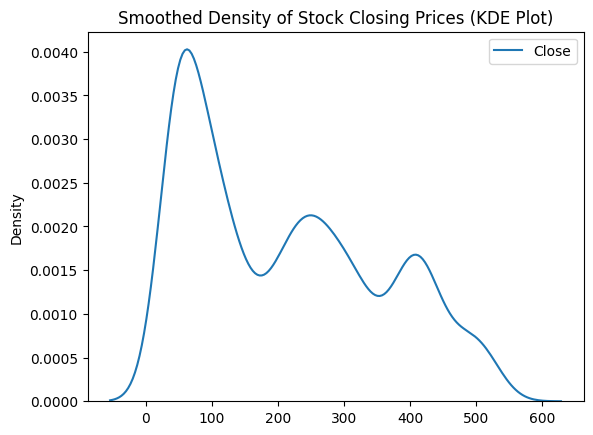

In [12]:
#Visualizations

plt.title('Distribution of Stock Closing Prices (Histogram)')
sns.histplot(stock_data)
plt.show()

plt.title('Smoothed Density of Stock Closing Prices (KDE Plot)')
sns.kdeplot(stock_data)
plt.show()

In [13]:
# Time series decomposition (multiplicative model)
result = seasonal_decompose(stock_data, model='multiplicative', period=365)

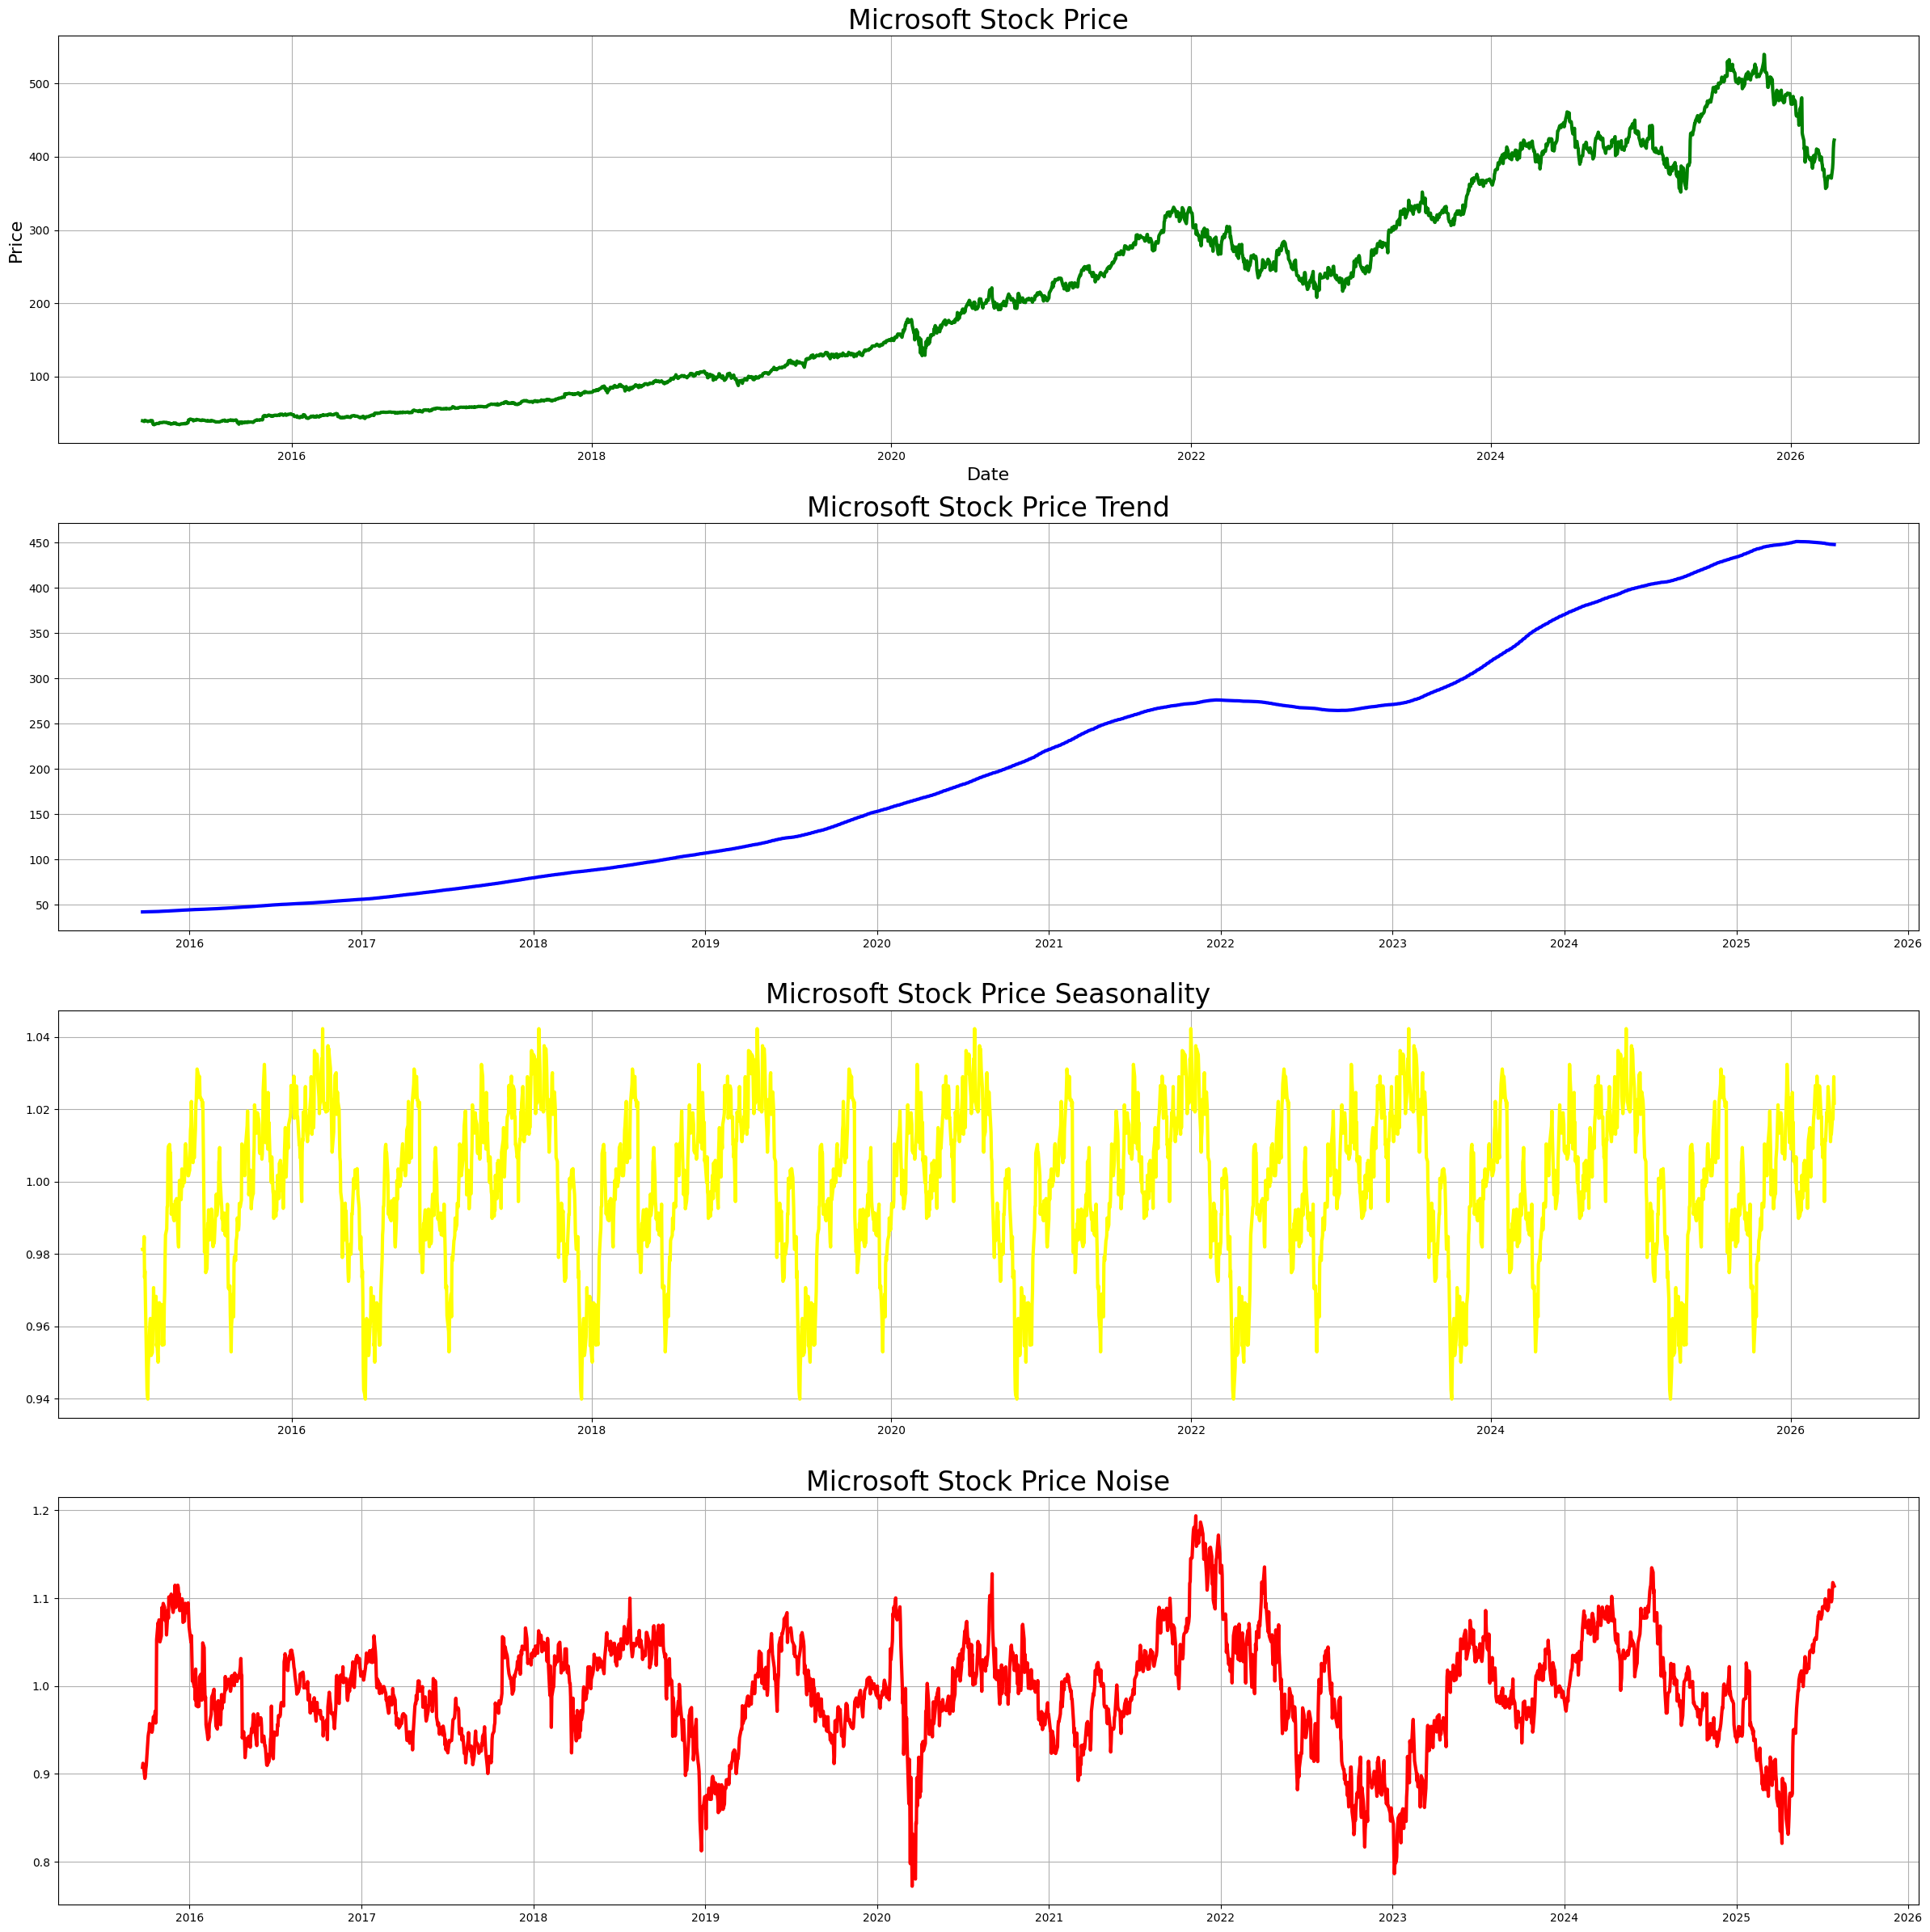

In [14]:
#Visualizing the decomposition
plt.figure(figsize=(24,24))

plt.subplot(4,1,1)
plt.plot(stock_data,color = 'green',linewidth = 3)
plt.xlabel('Date',fontsize=16)
plt.ylabel('Price',fontsize=16)
plt.title('Microsoft Stock Price',fontsize=24)
plt.grid()

plt.subplot(4,1,2)
plt.plot(result.trend,color = 'Blue',linewidth = 3)
plt.title('Microsoft Stock Price Trend',fontsize=24)
plt.grid()

plt.subplot(4,1,3)
plt.plot(result.seasonal,color = 'Yellow',linewidth = 3)
plt.title('Microsoft Stock Price Seasonality',fontsize=24)
plt.grid()

plt.subplot(4,1,4)
plt.plot(result.resid,color = 'Red',linewidth = 3)
plt.title('Microsoft Stock Price Noise',fontsize=24)
plt.grid()

plt.tight_layout()
plt.show()

In [15]:
# Time series decomposition (Additive model)
result = seasonal_decompose(stock_data, model='additive', period=365)

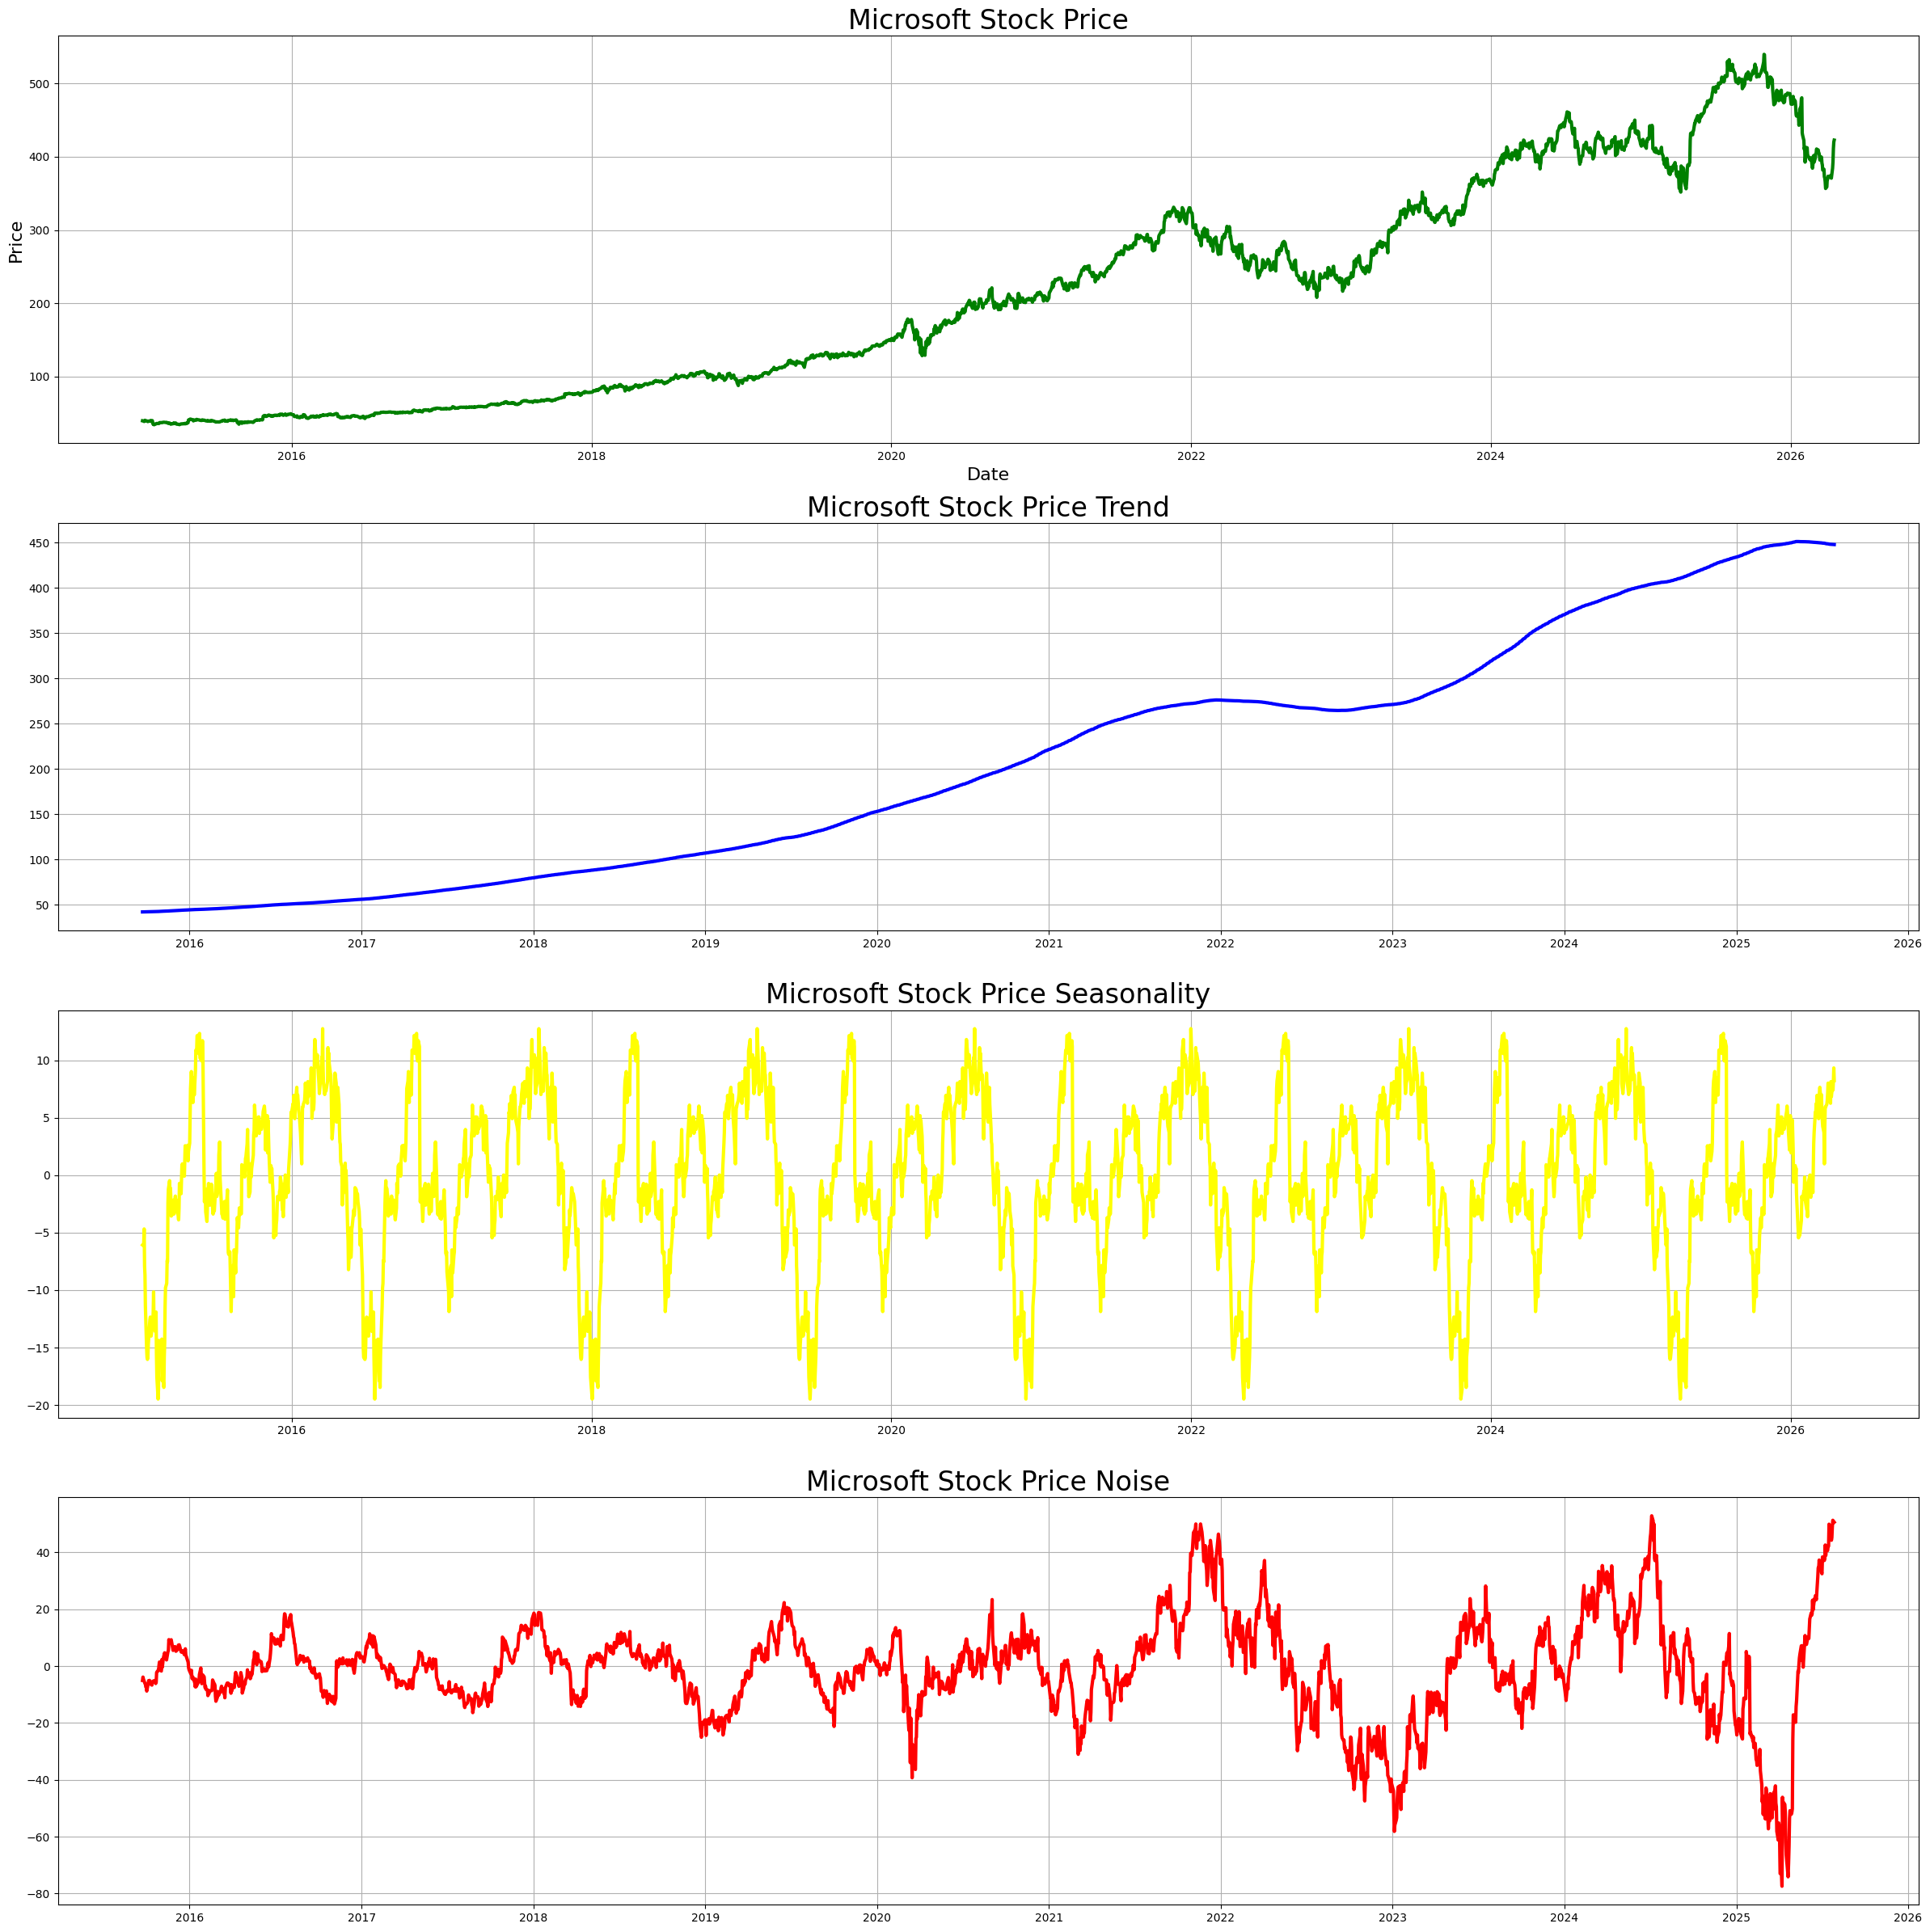

In [16]:
#Visualizing the decomposition
plt.figure(figsize=(24,24))

plt.subplot(4,1,1)
plt.plot(stock_data,color = 'green',linewidth = 3)
plt.xlabel('Date',fontsize=16)
plt.ylabel('Price',fontsize=16)
plt.title('Microsoft Stock Price',fontsize=24)
plt.grid()

plt.subplot(4,1,2)
plt.plot(result.trend,color = 'Blue',linewidth = 3)
plt.title('Microsoft Stock Price Trend',fontsize=24)
plt.grid()

plt.subplot(4,1,3)
plt.plot(result.seasonal,color = 'Yellow',linewidth = 3)
plt.title('Microsoft Stock Price Seasonality',fontsize=24)
plt.grid()

plt.subplot(4,1,4)
plt.plot(result.resid,color = 'Red',linewidth = 3)
plt.title('Microsoft Stock Price Noise',fontsize=24)
plt.grid()

plt.tight_layout()
plt.show()

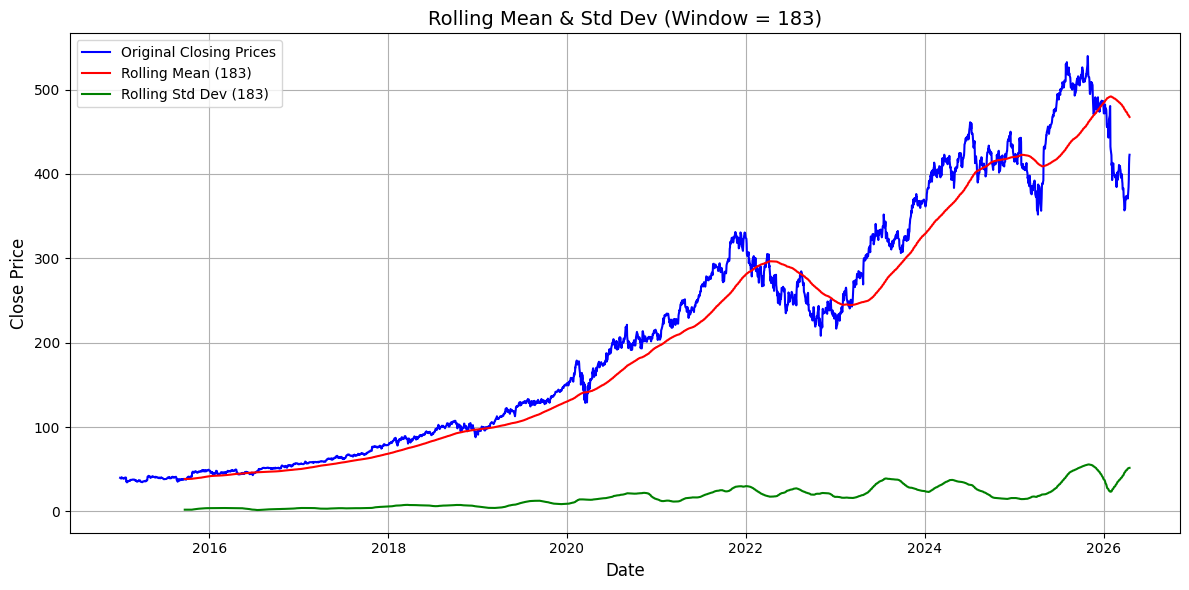

In [17]:
# Rolling mean and standard deviation
window_size = 183
rolling_mean = stock_data['Close'].rolling(window=window_size).mean()
rolling_std = stock_data['Close'].rolling(window=window_size).std()


plt.figure(figsize=(12, 6))
plt.plot(stock_data['Close'], label='Original Closing Prices', color='blue')
plt.plot(rolling_mean, label=f'Rolling Mean ({window_size})', color='red')
plt.plot(rolling_std, label=f'Rolling Std Dev ({window_size})', color='green')


plt.title(f'Rolling Mean & Std Dev (Window = {window_size})', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Close Price', fontsize=12)
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

In [19]:
# Stationarity Check

def Adf_test(data,alpha=0.05):
    val = adfuller(data)[1]
    if val > alpha:
        print(f'P-value is {val.round(4)} which is more than {alpha} therefore data is  Non - Stationary ❌')
    else:
        print(f'P-value is {val.round(4)} which is less than {alpha} therefore data Stationary ✅' )

In [20]:
Adf_test(stock_data)

P-value is 0.9027 which is more than 0.05 therefore data is  Non - Stationary ❌


In [21]:
# Visualizations also suggest that data is non-stationary
# Let's check if first differntiation makes any changes
# stock_data.head().diff().dropna()

Adf_test(stock_data.diff().dropna())

# After doing the first differentation the data becomes stationary

P-value is 0.0 which is less than 0.05 therefore data Stationary ✅


In [23]:
# I am conducting another test for stationarity just to be sure.

def Kpss_test(data,alpha=0.05):
    val = kpss(data)[1]
    if val > alpha:
        print('Stationary ✅')
    else:
        print('Non - Stationary ❌')

Kpss_test(stock_data)
Kpss_test(stock_data.diff().dropna())

Non - Stationary ❌
Stationary ✅


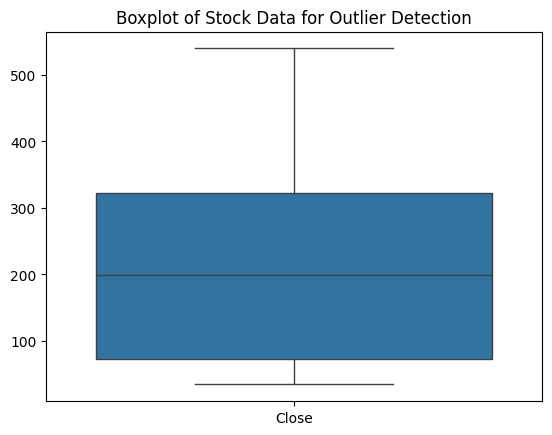

In [24]:
# Outlier detection
plt.title('Boxplot of Stock Data for Outlier Detection')
sns.boxplot(stock_data)
plt.show()

# Visualization shows that we don't have any outliers therefore we don't need to handle them

<Figure size 1000x400 with 0 Axes>

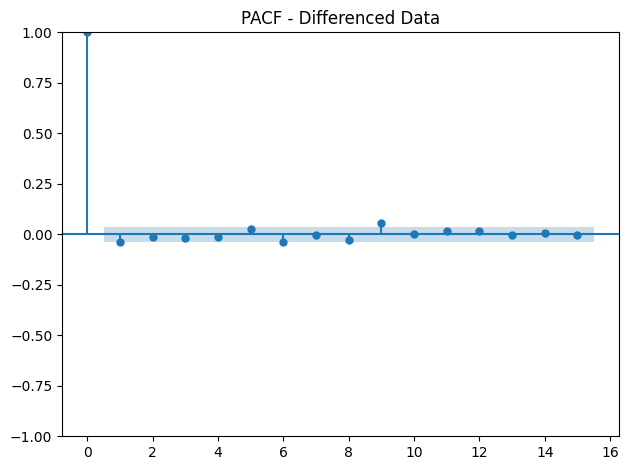

<Figure size 1000x400 with 0 Axes>

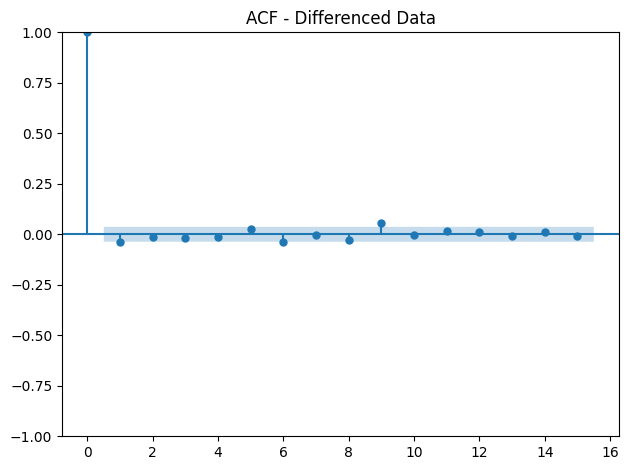

In [25]:
#Generating ACF and PACF plots

diff_data = stock_data.diff().dropna()

plt.figure(figsize=(10, 4))
plot_pacf(diff_data, lags=15)
plt.title("PACF - Differenced Data")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plot_acf(diff_data, lags=15)
plt.title("ACF - Differenced Data")
plt.tight_layout()
plt.show()

<Figure size 1000x400 with 0 Axes>

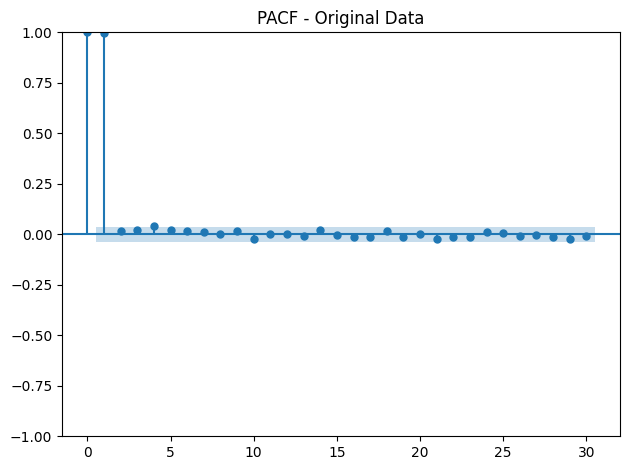

<Figure size 1000x400 with 0 Axes>

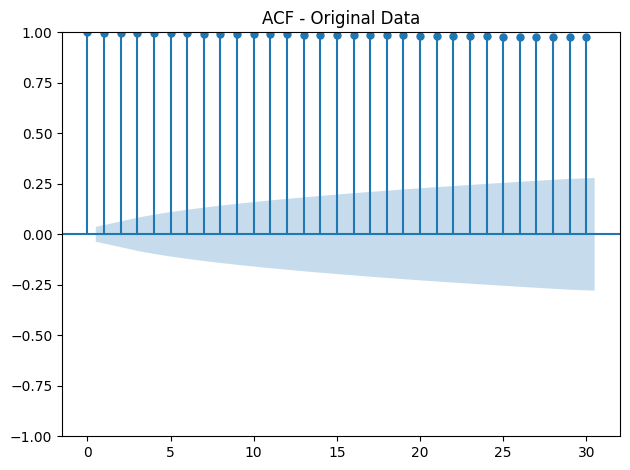

In [26]:
# --- PACF and ACF on Original Data (not recommended for ARIMA, just for comparison) ---
plt.figure(figsize=(10, 4))
plot_pacf(stock_data, lags=30)
plt.title("PACF - Original Data")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plot_acf(stock_data, lags=30)
plt.title("ACF - Original Data")
plt.tight_layout()
plt.show()

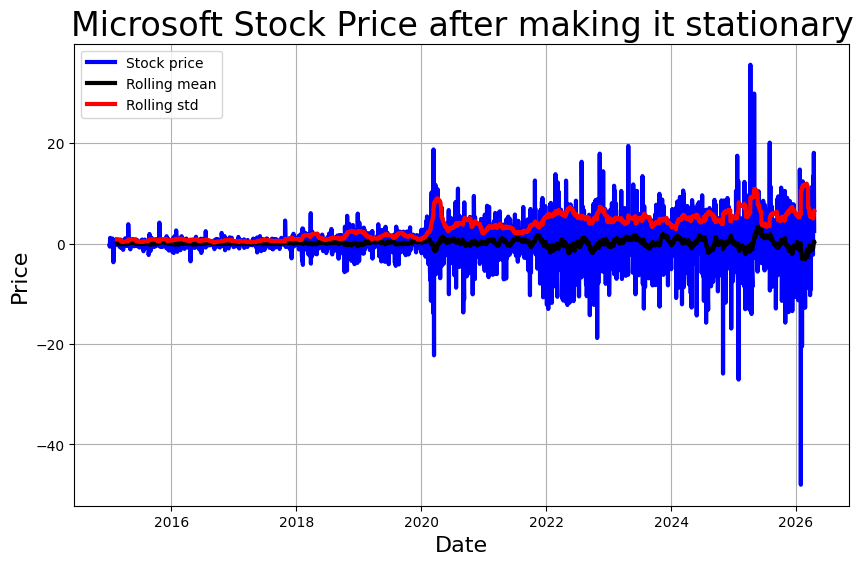

In [27]:
#Visualizing the decomposition
plt.figure(figsize=(10,6))

plt.plot(diff_data, color='blue', linewidth=3, label='Stock price')
plt.plot(diff_data.rolling(window=30).mean(), color='black', linewidth=3, label='Rolling mean')
plt.plot(diff_data.rolling(window=30).std(), color='red', linewidth=3, label='Rolling std')

plt.xlabel('Date', fontsize=16)
plt.ylabel('Price', fontsize=16)
plt.title('Microsoft Stock Price after making it stationary', fontsize=24)
plt.grid()
plt.legend()
plt.show()


# Model building


In [28]:
# Splitting the data into training and testing sets
train_size = int(len(stock_data) * 0.8)
train_data = stock_data[:train_size]

test_data = stock_data[train_size:]

In [29]:
#Print the size
print(f'Shape of data {stock_data.shape}\nSize of training data {train_size}\nSize of testing Data {2621-2096}')

Shape of data (2839, 1)
Size of training data 2271
Size of testing Data 525


In [30]:
history = [x for x in train_data['Close']]

print(history)

[39.76767349243164, 39.40199279785156, 38.82367706298828, 39.31694412231445, 40.47357177734375, 40.13338088989258, 39.63161087036133, 39.42749786376953, 39.08730697631836, 38.67909240722656, 39.32544708251953, 39.453006744384766, 39.05329513549805, 40.08236312866211, 40.1248779296875, 39.980308532714844, 36.2807731628418, 35.030601501464844, 35.727989196777344, 34.35873794555664, 35.10714340209961, 35.379295349121094, 35.583404541015625, 36.10218811035156, 36.068172454833984, 36.02565002441406, 36.229774475097656, 36.04265594482422, 36.646480560302734, 37.309844970703125, 37.32697296142578, 37.28414535522461, 37.25846481323242, 37.566810607910156, 37.815189361572266, 37.7638053894043, 37.67816925048828, 37.73811340332031, 37.5582275390625, 37.583919525146484, 37.07003402709961, 36.881587982177734, 36.924415588378906, 36.28202438354492, 36.70171356201172, 35.999385833740234, 35.95654296875, 35.13430404663086, 35.44264221191406, 35.59682083129883, 35.71672058105469, 36.40193557739258, 36


# Arima Model


In [31]:
model = ARIMA(history,order=(1,1,1))
fit = model.fit()

In [32]:
fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 2271
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -5872.612
Date:                Sun, 19 Apr 2026   AIC                          11751.223
Time:                        03:41:13   BIC                          11768.406
Sample:                             0   HQIC                         11757.492
                               - 2271                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2623      0.104      2.512      0.012       0.058       0.467
ma.L1         -0.3663      0.102     -3.578      0.000      -0.567      -0.166
sigma2        10.3421      0.163     63.312      0.000      10.022      10.662
===================================================================================
Ljung-Box (L1) (Q):                   0.03   Jarque-Bera (JB):              2963.38
Prob(Q):                              0.86   Prob(JB):                         0.00
Heteroskedasticity (H):              48.72   Skew:                            -0.15
Prob(H) (two-sided):                  0.00   Kurtosis:                         8.59
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [33]:
result = fit.forecast(steps=len(test_data))

In [34]:
np.sqrt(mean_squared_error(test_data,result))

np.float64(74.96139908739717)

In [35]:
def train_arima_model(X, y, arima_order):
    history = [x for x in X]
    predictions = []

    for i in range(len(y)):
        model = ARIMA(history, order=arima_order)
        model_fit = model.fit()
        forecast = model_fit.forecast()
        predictions.append(forecast[0])
        history.append(y[i])

    rmse = np.sqrt(mean_squared_error(y, predictions))
    return rmse, predictions

In [ ]:
rmse_score, forecasted_values = train_arima_model(train_data['Close'], test_data['Close'], [1,1,1])

In [ ]:
# Use the test_data index directly
forecast_series = pd.Series(forecasted_values, index=test_data.index)

# Plot
plt.figure(figsize=(12, 6))
plt.plot(train_data['Close'], label='Train')
plt.plot(test_data['Close'], label='Test', color='black')
plt.plot(forecast_series, label='Forecast', linestyle='--', color='red')
plt.legend()
plt.title('ARIMA Forecast with Train and Test')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.show()

In [ ]:
def evaluate_models(train_data, test_data, p_values, d_values, q_values):
    best_score, best_cfg = float('inf'), None

    print(f"Evaluating {len(p_values) * len(d_values) * len(q_values)} ARIMA models...")

    for p in p_values:
        for d in d_values:
            for q in q_values:
                order = (p, d, q)
                try:
                    model = ARIMA(train_data, order=order)
                    model_fit = model.fit()
                    predictions = model_fit.predict(
                        start=len(train_data),
                        end=len(train_data) + len(test_data) - 1,
                        dynamic=True
                    )
                    if isinstance(test_data, pd.Series):
                        predictions.index = test_data.index

                    rmse = np.sqrt(mean_squared_error(test_data, predictions))
                    print(f'ARIMA{order} RMSE: {round(rmse,4)}')

                    if rmse < best_score:
                        best_score = rmse
                        best_cfg = order
                except:
                    continue

    print("\n--- Evaluation Complete ---")
    print(f'Best ARIMA{best_cfg} RMSE: {best_score:.4f}')

    return best_cfg

In [ ]:
p = range(0,3)
d = range(0,3)
q = range(0,3)

Output= evaluate_models(train_data,test_data,p,d,q)

Evaluating 27 ARIMA models...
ARIMA(0, 0, 0) RMSE: 278.3295
ARIMA(0, 0, 1) RMSE: 278.2555
ARIMA(0, 0, 2) RMSE: 278.2146
ARIMA(0, 1, 0) RMSE: 114.7128
ARIMA(0, 1, 1) RMSE: 114.7928
ARIMA(0, 1, 2) RMSE: 114.8813
ARIMA(0, 2, 0) RMSE: 118.9354
ARIMA(0, 2, 1) RMSE: 76.4899
ARIMA(0, 2, 2) RMSE: 76.0715
ARIMA(1, 0, 0) RMSE: 120.4159
ARIMA(1, 0, 1) RMSE: 115.4937
ARIMA(1, 0, 2) RMSE: 126.214
ARIMA(1, 1, 0) RMSE: 114.764
ARIMA(1, 1, 1) RMSE: 114.8961
ARIMA(1, 1, 2) RMSE: 114.9031
ARIMA(1, 2, 0) RMSE: 360.9178
ARIMA(1, 2, 1) RMSE: 77.1231
ARIMA(1, 2, 2) RMSE: 76.9962
ARIMA(2, 0, 0) RMSE: 115.8649
ARIMA(2, 0, 1) RMSE: 131.1214
ARIMA(2, 0, 2) RMSE: 126.991
ARIMA(2, 1, 0) RMSE: 114.8769
ARIMA(2, 1, 1) RMSE: 114.9033
ARIMA(2, 1, 2) RMSE: 114.9066
ARIMA(2, 2, 0) RMSE: 54.8213
ARIMA(2, 2, 1) RMSE: 77.2494
ARIMA(2, 2, 2) RMSE: 77.3599

--- Evaluation Complete ---
Best ARIMA(2, 2, 0) RMSE: 54.8213


In [ ]:
def forecast_arima_model(train_data, arima_order, n_forecast_steps):

    print(f"Training ARIMA{arima_order} model on data of length {len(train_data)}...")

    model = ARIMA(train_data, order=arima_order)
    model_fit = model.fit()
    print(f"Forecasting {n_forecast_steps} steps into the future...")
    forecasts = model_fit.forecast(steps=n_forecast_steps,alpha=0.05)
    return forecasts,model_fit

In [ ]:
len(test_data)

545

In [ ]:
fc, model_fitted= forecast_arima_model(train_data,[2,2,2],len(test_data))
# fc,model_fitted = forecast_arima_model(train_data,[2,2,2],1050)

Training ARIMA[2, 2, 2] model on data of length 2178...
Forecasting 545 steps into the future...


In [ ]:
# fc_index = pd.date_range(start=test_data.index[0], periods=1050, freq=test_data.index.freq)
fc.index = test_data.index

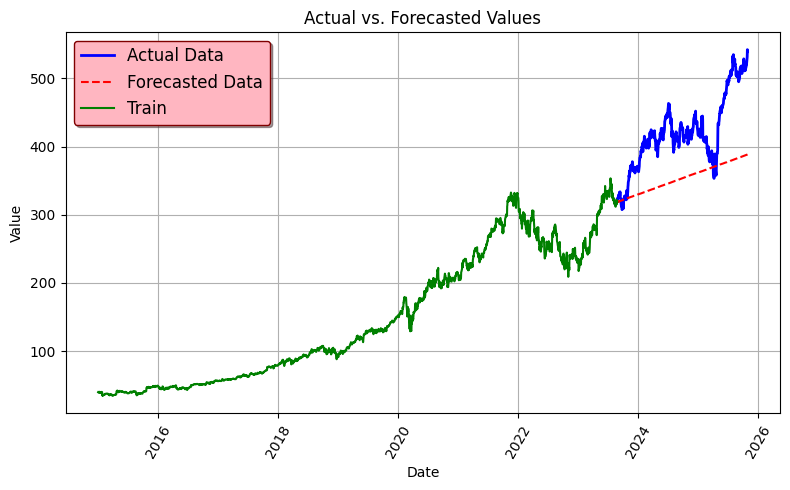

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(test_data, label='Actual Data', color='blue', linewidth=2)
plt.plot(fc, label='Forecasted Data', color='red', linestyle='--', linewidth=1.5)
plt.plot(train_data['Close'], label='Train',color='Green')
plt.xticks(rotation=60)

plt.xlabel('Date')
plt.ylabel('Value')
plt.title('Actual vs. Forecasted Values')

plt.legend(fontsize = 12, shadow=True,facecolor = 'LightPink',edgecolor='maroon')
plt.grid()
plt.tight_layout()
plt.show()

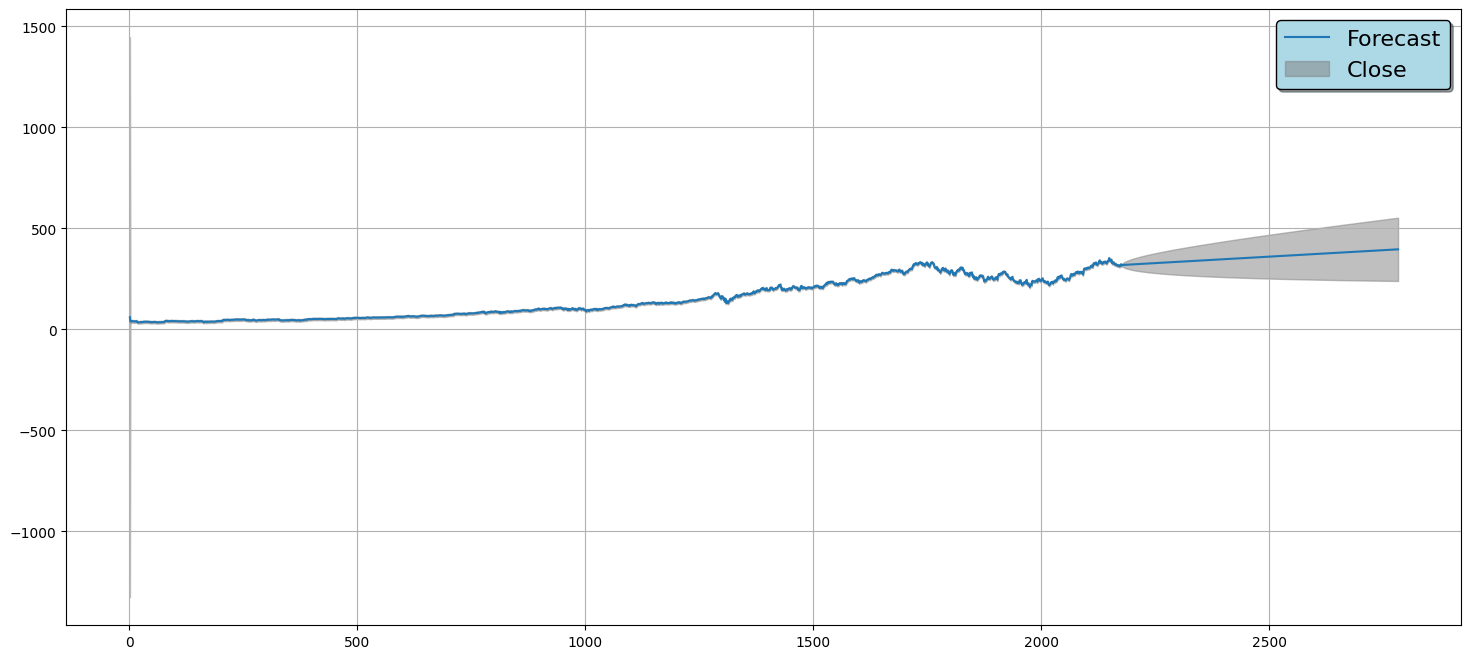

In [ ]:
from statsmodels.graphics.tsaplots import plot_predict
plt.figure(figsize=(18, 8))
ax = plt.subplot(1, 1, 1)

plot_predict(result=model_fitted, start=1, end=len(stock_data)+60, ax=ax)
plt.grid()

plt.legend(['Forecast', 'Close', '95% confidence interval'],fontsize=16, shadow=True, facecolor='lightblue', edgecolor='black')

plt.show()


# Sarima Model


In [ ]:
# Fit SARIMA model
model = SARIMAX(train_data, order=(1,1,1), seasonal_order=(1,1,1,30))
model_fit = model.fit()


forecast = model_fit.forecast(steps=len(test_data))
forecast.index = test_data.index

In [ ]:
rmse = np.sqrt(mean_squared_error(test_data,forecast))
print(rmse)

78.02559541027283


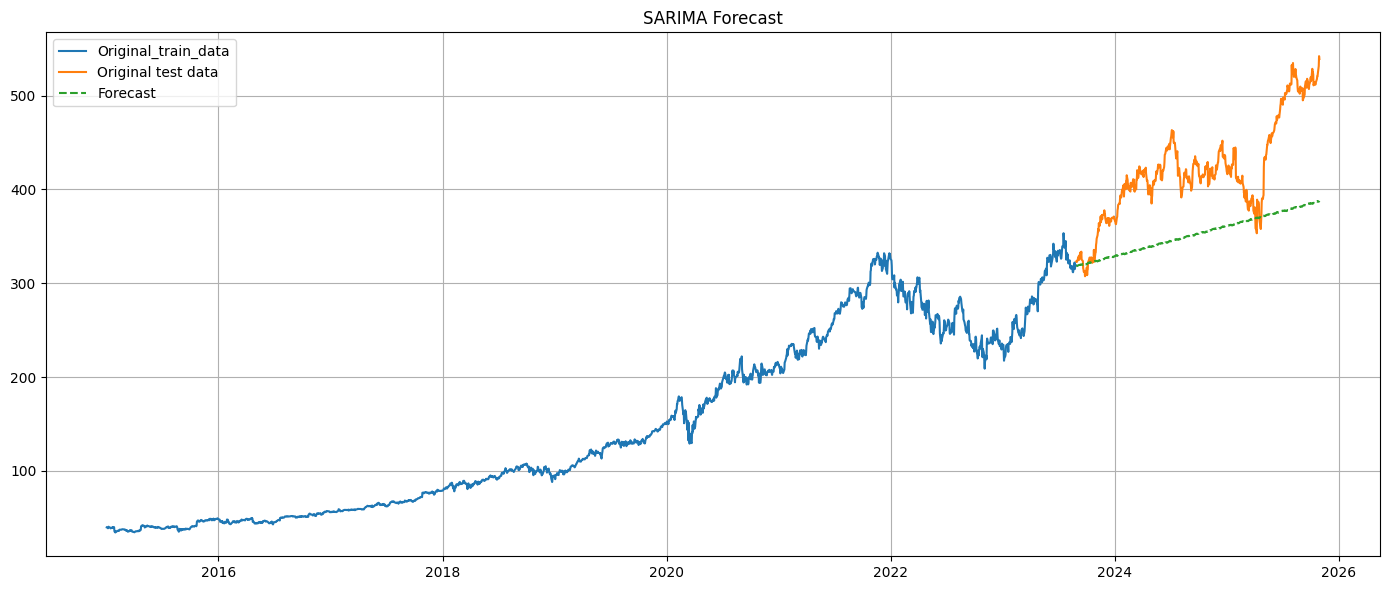

In [ ]:
plt.figure(figsize=(14,6))
plt.plot(train_data, label='Original_train_data')
plt.plot(test_data, label='Original test data')
plt.plot(forecast, label='Forecast', linestyle='--')
plt.title('SARIMA Forecast')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# Define endogenous and exogenous variables
y = df['Close']
X = df[['Open', 'High', 'Low', 'Volume']]

# Define train/test split index
split_index = int(len(stock_data) * 0.8)

# Split data
y_train, y_test = y[:split_index], y[split_index:]
X_train, X_test = X[:split_index], X[split_index:]


print(f"Training samples: {len(y_train)}")
print(f"Testing samples: {len(y_test)}")

Training samples: 2178
Testing samples: 545



# SARIMAX model


In [ ]:
# Fit SARIMAX model
model = SARIMAX(y_train, exog=X_train, order=(1, 1, 1), seasonal_order=(1, 1, 1, 30))
model_fit = model.fit()


In [ ]:
forecast = model_fit.forecast(steps=len(test_data), exog=X_test)
forecast.index=X_test.index

In [ ]:
rmse = np.sqrt(mean_squared_error(y_test,forecast))
print(rmse)

8.914807739698837


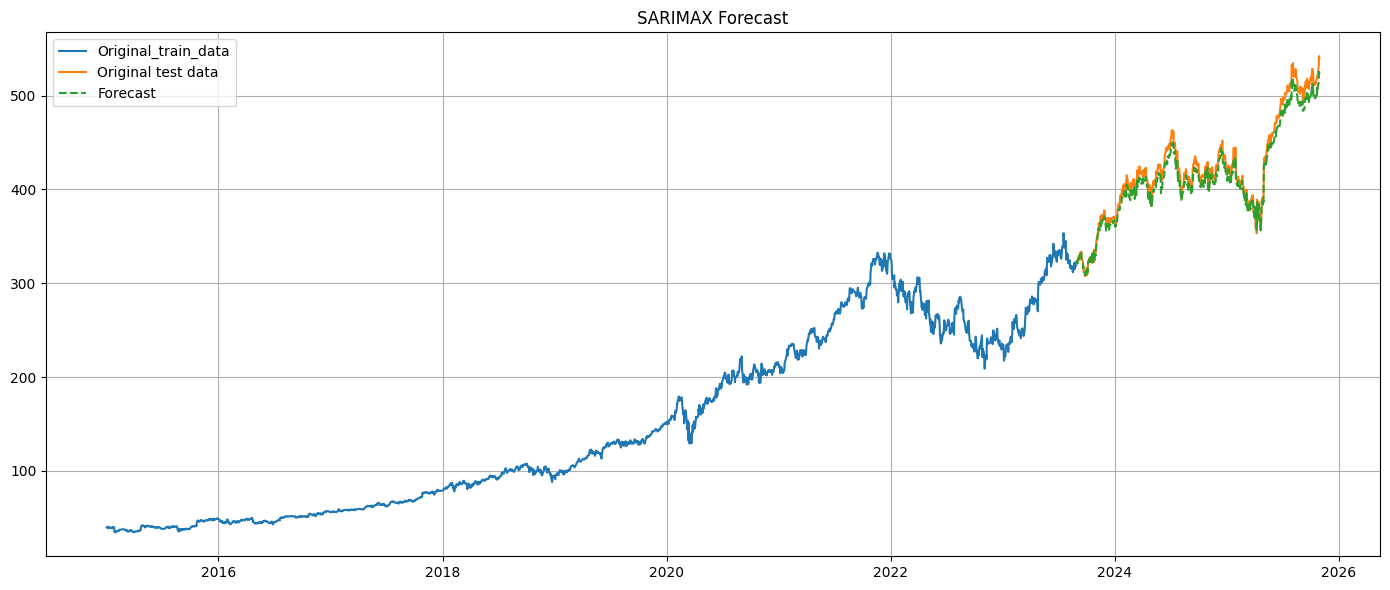

In [ ]:
plt.figure(figsize=(14,6))
plt.plot(y_train, label='Original_train_data')
plt.plot(y_test, label='Original test data')
plt.plot(forecast, label='Forecast', linestyle='--')
plt.title('SARIMAX Forecast')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**Prophet**

In [39]:
from google.colab import files
uploaded = files.upload()
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt

Saving Microsoft (1).xlsx to Microsoft (1).xlsx


In [42]:
df = pd.read_excel("Microsoft (1).xlsx")
df.head()

,Date,Close,High,Low,Open,Volume
0,2015-01-02,39.998703,40.563270,39.810516,39.913164,27913900
1,2015-01-05,39.630882,39.973042,39.562448,39.665096,39673900
2,2015-01-06,39.049198,39.990141,38.955103,39.673643,36447900
3,2015-01-07,39.545338,39.742080,38.912340,39.331487,29114100
4,2015-01-08,40.708691,40.845555,39.964490,39.990151,29645200


In [43]:
print(df.columns)
df = df.rename(columns={'Date': 'ds', 'Close': 'y'})
df['ds'] = pd.to_datetime(df['ds'])
df.dropna(inplace=True)
df.info()

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2623 entries, 0 to 2622
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   ds      2623 non-null   datetime64[ns]
 1   y       2623 non-null   float64       
 2   High    2623 non-null   float64       
 3   Low     2623 non-null   float64       
 4   Open    2623 non-null   float64       
 5   Volume  2623 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 123.1 KB


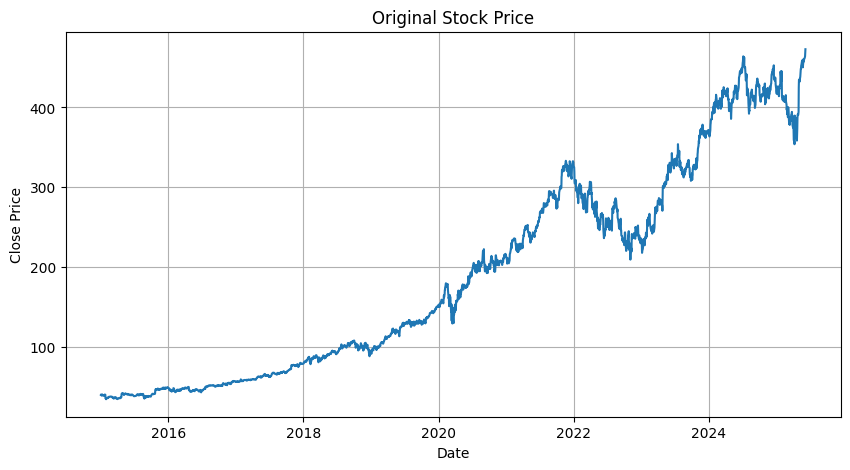

In [44]:
plt.figure(figsize=(10, 5))
plt.plot(df['ds'], df['y'])
plt.title('Original Stock Price')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.grid(True)
plt.show()

In [45]:
model = Prophet()
model.fit(df)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [46]:
future = model.make_future_dataframe(periods=90)
forecast = model.predict(future)

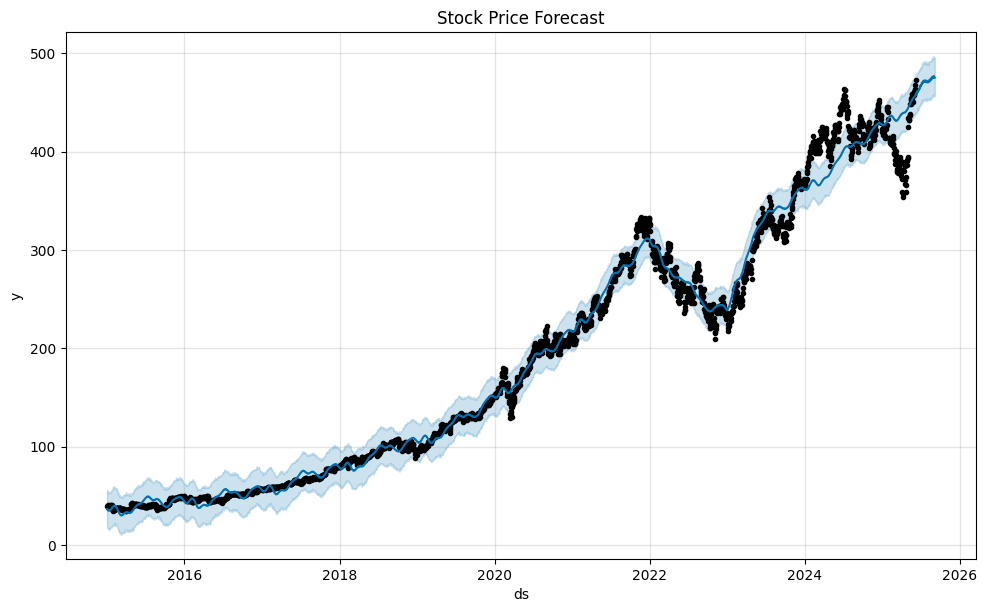

In [47]:
##%%
fig1 = model.plot(forecast)
plt.title("Stock Price Forecast")
plt.show()

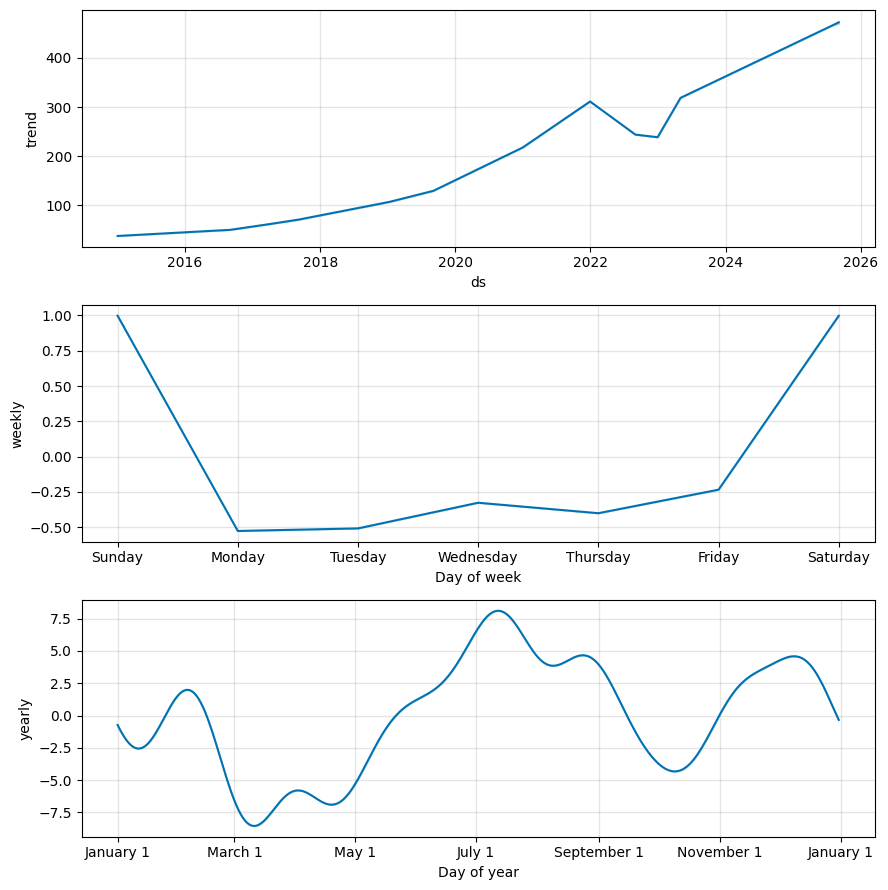

In [48]:
fig2 = model.plot_components(forecast)
plt.show()

In [49]:
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].to_csv('prophet_forecast_output.csv', index=False)